# Architecture & Models in Practice
## By: Parinthapat Pengpun
## Super AI Engineer -- Computer Vision Lecture (Level 1)

This notebook is your **guided tour** of the model landscape:
1. Where to find pretrained models (HuggingFace, timm, Ultralytics)
2. CNN architecture tour -- which model to pick and why
3. Transfer learning code patterns (freeze, unfreeze, fine-tune)
4. Vision Transformers -- simple explanation + inference
5. Detection model comparison (YOLO vs DETR)
6. SAM2 segmentation demo
7. Model selection cheat sheet

**Runtime:** Google Colab (free T4) -- total run time ~5 minutes

**Philosophy:** We are USING models, not building them. The question is always:
> *"Which model should I use and how do I load it?"*

---
## Cell Group 1: Setup (1 min)

In [1]:
!pip install -q torch torchvision timm transformers ultralytics matplotlib Pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00


In [3]:
import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import timm
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests
import io
import urllib

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"timm version: {timm.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
timm version: 1.0.25
GPU available: True
GPU: Tesla T4


Downloaded image: 600x300 pixels


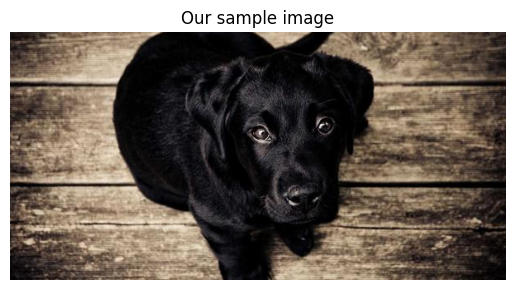

In [4]:
# Download a sample image (public domain from Unsplash)
url = "https://picsum.photos/id/237/600/300"
filepath = "local_image.png"
urllib.request.urlretrieve(url, filepath)

sample_image = Image.open(filepath).convert("RGB")
print(f"Downloaded image: {sample_image.size[0]}x{sample_image.size[1]} pixels")
plt.figure()
plt.imshow(sample_image)
plt.title("Our sample image")
plt.axis("off")
plt.show()

---
## Cell Group 2: Model Zoo Tour (8 min) -- CORE

There are **thousands** of pretrained models available for free.
You just need to know WHERE to find them and HOW to load them.

Three libraries you should know:
1. **HuggingFace** -- the "GitHub of ML models" (10,000+ vision models)
2. **timm** -- the secret weapon of Kaggle winners (800+ models)
3. **Ultralytics** -- the home of YOLO (detection made easy)

### 2a. HuggingFace Hub -- Classify any image in 2 lines

In [5]:
from transformers import pipeline

# Load a model in 2 lines
classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
result = classifier(sample_image)

print("HuggingFace prediction:")
for r in result:
    print(f"  {r['label']:30s}  {r['score']:.1%}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


HuggingFace prediction:
  Labrador retriever              92.8%
  flat-coated retriever           4.3%
  curly-coated retriever          0.8%
  golden retriever                0.2%
  Great Dane                      0.2%


### 2b. timm -- The Kaggle Winner's Secret Weapon

In [6]:
import timm

# See ALL available models
all_models = timm.list_models()
print(f"Total models available: {len(all_models)}")
print()

# Filter ResNet variants
resnet_models = timm.list_models('resnet*')
print(f"ResNet variants: {len(resnet_models)}")
print(f"  First 10: {resnet_models[:10]}")
print()

# Filter EfficientNet variants
effnet_models = timm.list_models('efficientnet*')
print(f"EfficientNet variants: {len(effnet_models)}")
print()

# Filter ViT variants
vit_models = timm.list_models('vit*')
print(f"ViT variants: {len(vit_models)}")

Total models available: 1284

ResNet variants: 75
  First 10: ['resnet10t', 'resnet14t', 'resnet18', 'resnet18d', 'resnet26', 'resnet26d', 'resnet26t', 'resnet32ts', 'resnet33ts', 'resnet34']

EfficientNet variants: 42

ViT variants: 207


In [9]:
# Load a model in 2 lines -- same API for ANY model in the library
model_timm = timm.create_model('resnet18', pretrained=True, num_classes=10)
print(f"Model: resnet18")
print(f"Parameters: {sum(p.numel() for p in model_timm.parameters()):,}")
print(f"Output classes: 10")
print()

# HACKATHON TIP: Change 'resnet18' to any model name from timm.list_models()
# and the rest of your code stays EXACTLY the same. That is the power of timm.

Model: resnet18
Parameters: 11,181,642
Output classes: 10



### 2c. Ultralytics YOLO -- Detection in 3 lines

In [10]:
# SPEAKER NOTE: "For detection: Ultralytics YOLO. Start with nano (n) -- smallest and fastest.
#   Only upgrade to small (s) if accuracy is not enough. Never start with large."
# RUN TIME: ~10 seconds (first-time model download)

from ultralytics import YOLO

# Load YOLO -- one line
yolo_model = YOLO('yolov8n.pt')  # nano = smallest, fastest

# Model sizes for reference:
print("YOLO model sizes:")
print("  yolov8n (nano)   -- 3.2M params  -- Start here!")
print("  yolov8s (small)  -- 11.2M params -- If nano isn't accurate enough")
print("  yolov8m (medium) -- 25.9M params -- Good GPU required")
print("  yolov8l (large)  -- 43.7M params -- Competition-level")
print()
print("Rule of thumb: start small, upgrade only if needed.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO model sizes:
  yolov8n (nano)   -- 3.2M params  -- Start here!
  yolov8s (small)  -- 11.2M params -- If nano isn't accurate enough
  yolov8m (medium) -- 25.9M params -- Good GPU required
  yolov8l (large)  -- 43.7M params -- Competition-level

Rule of thumb: start small, upgrade only if needed.


### 2d. Comparison: Which Library When?

| Library | Best For | # Models | Load Code |
|---------|----------|----------|----------|
| **torchvision** | Classification basics | ~30 | `models.resnet18(weights='IMAGENET1K_V1')` |
| **timm** | Kaggle competitions | 800+ | `timm.create_model('resnet18', pretrained=True)` |
| **HuggingFace** | ViT, DETR, cutting-edge | 10,000+ | `pipeline("image-classification", model="...")` |
| **Ultralytics** | YOLO detection | 5 sizes | `YOLO('yolov8n.pt')` |

**Hackathon rule:** Start with HuggingFace or timm for classification, Ultralytics for detection. Only explore other libraries if these do not solve your problem.

---
## Cell Group 3: CNN Architecture Tour -- Practical (5 min) -- CORE

You do not need to understand how these architectures work internally.
You need to know: **which one to pick, how to load it, and how big it is.**

In [11]:
import torchvision.models as models

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# --- The 4 models that matter ---

# 1. ResNet-18: The reliable workhorse
resnet18 = models.resnet18(weights='IMAGENET1K_V1')
print(f"ResNet-18:        {count_params(resnet18):>12,} params  |  Small quick model for protyping.")

# 2. ResNet-50: More capacity, still fast
resnet50 = models.resnet50(weights='IMAGENET1K_V1')
print(f"ResNet-50:        {count_params(resnet50):>12,} params  |  More accuracy. Use with a good GPU.")

# 3. EfficientNet-B0: Best accuracy per parameter
effnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
print(f"EfficientNet-B0:  {count_params(effnet):>12,} params  |  Best bang for buck. Fewer params, high accuracy.")

# 4. MobileNetV3: For when speed is everything
mobilenet = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
print(f"MobileNetV3-S:    {count_params(mobilenet):>12,} params  |  Phone/edge deployment. Very fast.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


ResNet-18:          11,689,512 params  |  Small quick model for protyping.
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


ResNet-50:          25,557,032 params  |  More accuracy. Use with a good GPU.
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 100MB/s] 


EfficientNet-B0:     5,288,548 params  |  Best bang for buck. Fewer params, high accuracy.
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 135MB/s]


MobileNetV3-S:       2,542,856 params  |  Phone/edge deployment. Very fast.


In [12]:
# Standard ImageNet preprocessing -- memorize these numbers!
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]      # ImageNet std
    ),
])

# Load ImageNet class labels
IMAGENET_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
try:
    imagenet_classes = requests.get(IMAGENET_URL, timeout=10).text.strip().split("\n")
except Exception:
    imagenet_classes = [f"class_{i}" for i in range(1000)]

# Preprocess the image
input_tensor = preprocess(sample_image).unsqueeze(0)  # Add batch dimension

# Run inference with all 4 models
model_dict = {
    "ResNet-18": resnet18,
    "ResNet-50": resnet50,
    "EfficientNet-B0": effnet,
    "MobileNetV3-S": mobilenet,
}

print("Predictions from each model:")
print("=" * 60)
for name, model in model_dict.items():
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        top_prob, top_idx = probs.topk(1)
        label = imagenet_classes[top_idx.item()]
        confidence = top_prob.item()
    print(f"  {name:20s}  =>  {label:25s}  ({confidence:.1%})")

Predictions from each model:
  ResNet-18             =>  Labrador retriever         (58.1%)
  ResNet-50             =>  Labrador retriever         (79.2%)
  EfficientNet-B0       =>  Labrador retriever         (87.1%)
  MobileNetV3-S         =>  Labrador retriever         (51.5%)


### Practical Decision Guide

| Situation | Pick This Model | Why |
|-----------|----------------|-----|
| Hackathon with limited GPU / quick prototype | **ResNet-18** | Fast to train, small, reliable |
| Want best accuracy per parameter | **EfficientNet-B0** | Fewer params, higher accuracy |
| Have a good GPU, need more capacity | **ResNet-50** | Proven workhorse, great for fine-tuning |
| Deploy on phone or edge device | **MobileNetV3** | Tiny, fast, designed for mobile |

**Default choice for hackathons:** Start with ResNet-18. Upgrade only if accuracy is not enough.

---
## Cell Group 4: Transfer Learning Code -- The Exact Patterns (5 min) -- CORE

Transfer learning has **3 scenarios**. Pick the one that matches your dataset size.

All three start the same: load a pretrained model and replace the classification head.

In [13]:
# ============================================
# SCENARIO 1: Tiny dataset (<500 images)
# Strategy: Freeze everything, train head only
# ============================================

NUM_CLASSES = 5  # CHANGE THIS to your number of classes

model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze ALL layers -- nothing in the backbone will change
for param in model.parameters():
    param.requires_grad = False

# Replace the classification head with YOUR number of classes
model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)

# Only the new head will be trained
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Verify: how many parameters are trainable?
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Scenario 1: Freeze all, train head only")
print(f"  Trainable params: {trainable:,} / {total:,} ({trainable/total:.1%})")
print(f"  Learning rate: 0.001")
print(f"  Best for: <500 images, quick prototyping")

Scenario 1: Freeze all, train head only
  Trainable params: 2,565 / 11,179,077 (0.0%)
  Learning rate: 0.001
  Best for: <500 images, quick prototyping


In [14]:
# ============================================
# SCENARIO 2: Medium dataset (500-5000 images)
# Strategy: Unfreeze last few layers
# ============================================

NUM_CLASSES = 5  # CHANGE THIS

model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4 (the last residual block)
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace the head
model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)

# Different learning rates: lower for unfrozen layers, higher for new head
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.0001},   # Gentle updates
    {'params': model.fc.parameters(), 'lr': 0.001},         # Faster learning
])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Scenario 2: Unfreeze last block + head")
print(f"  Trainable params: {trainable:,} / {total:,} ({trainable/total:.1%})")
print(f"  LR for layer4: 0.0001 (gentle)")
print(f"  LR for head:   0.001  (faster)")
print(f"  Best for: 500-5000 images")

Scenario 2: Unfreeze last block + head
  Trainable params: 8,396,293 / 11,179,077 (75.1%)
  LR for layer4: 0.0001 (gentle)
  LR for head:   0.001  (faster)
  Best for: 500-5000 images


In [15]:
# ============================================
# SCENARIO 3: Large dataset (5000+ images)
# Strategy: Fine-tune everything with small LR
# ============================================

NUM_CLASSES = 5  # CHANGE THIS

model = models.resnet18(weights='IMAGENET1K_V1')

# Replace the head
model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)

# Train EVERYTHING with a small learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Scenario 3: Fine-tune everything")
print(f"  Trainable params: {trainable:,} / {total:,} ({trainable/total:.1%})")
print(f"  Learning rate: 0.0001 (small -- important!)")
print(f"  Best for: 5000+ images, when Scenario 1 or 2 plateau")

Scenario 3: Fine-tune everything
  Trainable params: 11,179,077 / 11,179,077 (100.0%)
  Learning rate: 0.0001 (small -- important!)
  Best for: 5000+ images, when Scenario 1 or 2 plateau


### Transfer Learning Decision Summary

| Dataset Size | Strategy | What to Freeze | Learning Rate |
|-------------|----------|----------------|---------------|
| < 500 images | **Scenario 1** -- Head only | Everything except `model.fc` | 0.001 |
| 500 - 5000 | **Scenario 2** -- Last block + head | Everything except `layer4` + `fc` | 0.0001 / 0.001 |
| 5000+ | **Scenario 3** -- Full fine-tune | Nothing frozen | 0.0001 |

**Always start with Scenario 1.** It is the fastest and safest. Only move to Scenario 2 or 3 if accuracy is not good enough.

---
## Cell Group 5: Vision Transformers -- Simple (8 min) -- CORE

You already know transformers from GPT and LLMs. ViT applies the **same idea** to images.

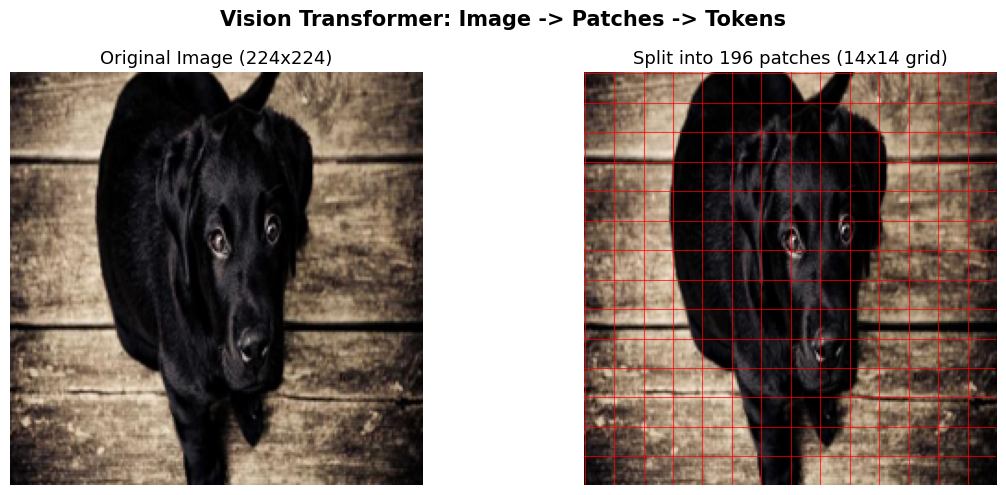

Each patch is 16x16 pixels
Total patches (tokens): 196
Just like a sentence with 196 words -- each patch 'attends' to all others


In [16]:
# Visualize: image split into 16x16 patches
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original image
axes[0].imshow(sample_image.resize((224, 224)))
axes[0].set_title("Original Image (224x224)", fontsize=13)
axes[0].axis('off')

# Right: image with 16x16 patch grid overlay
img_resized = sample_image.resize((224, 224))
axes[1].imshow(img_resized)
patch_size = 16
for i in range(0, 224, patch_size):
    axes[1].axhline(y=i, color='red', linewidth=0.8, alpha=0.7)
    axes[1].axvline(x=i, color='red', linewidth=0.8, alpha=0.7)
num_patches = (224 // patch_size) ** 2
axes[1].set_title(f"Split into {num_patches} patches ({224//patch_size}x{224//patch_size} grid)", fontsize=13)
axes[1].axis('off')

plt.suptitle("Vision Transformer: Image -> Patches -> Tokens", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Each patch is {patch_size}x{patch_size} pixels")
print(f"Total patches (tokens): {num_patches}")
print(f"Just like a sentence with {num_patches} words -- each patch 'attends' to all others")

### How ViT Works (No Math Version)

1. **Split** the image into 16x16 patches (like tiles)
2. **Flatten** each patch into a vector (like turning each tile into a "word")
3. **Add position info** so the model knows where each patch is
4. **Feed into a Transformer** -- every patch can "look at" every other patch (attention)
5. **Classify** based on a special `[CLS]` token (same idea as BERT)

**CNN vs ViT analogy:**
- CNN = reads a book line by line, builds understanding gradually
- ViT = sees the whole page at once, decides what matters

In [17]:
from transformers import ViTForImageClassification, ViTImageProcessor

# Load ViT model and processor
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
vit_model.eval()

# Run inference
inputs = processor(images=sample_image, return_tensors="pt")
with torch.no_grad():
    outputs = vit_model(**inputs)

# Get top predictions
probs = torch.softmax(outputs.logits, dim=1)
top5_probs, top5_indices = probs.topk(5)

print("ViT Predictions (top 5):")
for i in range(5):
    label = vit_model.config.id2label[top5_indices[0][i].item()]
    prob = top5_probs[0][i].item()
    print(f"  {label:30s}  {prob:.1%}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT Predictions (top 5):
  Labrador retriever              92.8%
  flat-coated retriever           4.3%
  curly-coated retriever          0.8%
  golden retriever                0.2%
  Great Dane                      0.2%


In [18]:
# ResNet-50 prediction (for comparison)
resnet50.eval()
with torch.no_grad():
    resnet_out = resnet50(input_tensor)
    resnet_probs = torch.softmax(resnet_out, dim=1)
    resnet_top_prob, resnet_top_idx = resnet_probs.topk(1)

resnet_label = imagenet_classes[resnet_top_idx.item()]
resnet_conf = resnet_top_prob.item()

# ViT prediction
vit_label = vit_model.config.id2label[top5_indices[0][0].item()]
vit_conf = top5_probs[0][0].item()

print("Side-by-side comparison:")
print(f"  ResNet-50:  {resnet_label:25s}  ({resnet_conf:.1%})")
print(f"  ViT-Base:   {vit_label:25s}  ({vit_conf:.1%})")
print()
print("Both architectures work. The best choice depends on your data.")

Side-by-side comparison:
  ResNet-50:  Labrador retriever         (79.2%)
  ViT-Base:   Labrador retriever         (92.8%)

Both architectures work. The best choice depends on your data.


### CNN vs ViT: Which One to Pick?

| | CNN (ResNet) | ViT |
|--|-------------|-----|
| Small data (<1000 images) | Better -- built-in spatial bias helps | Tends to overfit |
| Large data (>10,000 images) | Good | Better -- learns flexible patterns |
| Training speed | Faster | Slower |
| Model size | Smaller | Larger |
| GPU memory | Less | More |
| **Hackathon default** | **Start here** | Try if CNN plateaus |

**Honest advice:** With transfer learning, both work great. Try both and pick whichever scores higher on your validation set.

---
## Cell Group 6: Detection Models in Practice (5 min) -- FLEX

Two main choices for object detection:
- **YOLO** (Ultralytics) -- fast, easy, hackathon default
- **DETR** (HuggingFace) -- transformer-based, more accurate on complex scenes

Detection test image loaded: 640x480


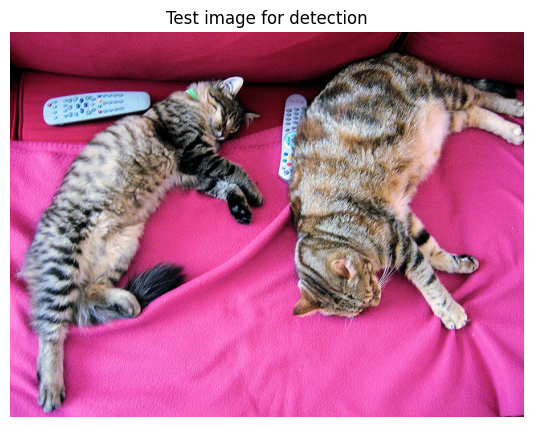

In [19]:
# Download a good detection test image (street scene with multiple objects)
det_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
try:
    det_image = Image.open(io.BytesIO(requests.get(det_url, timeout=10).content)).convert("RGB")
    print(f"Detection test image loaded: {det_image.size[0]}x{det_image.size[1]}")
except Exception:
    det_image = sample_image
    print("Using sample image for detection")

plt.figure(figsize=(8, 5))
plt.imshow(det_image)
plt.title("Test image for detection")
plt.axis('off')
plt.show()

=== YOLO Results ===
  cat              confidence=88.8%
  cat              confidence=82.5%
  remote           confidence=78.0%
  couch            confidence=36.0%
  remote           confidence=32.4%


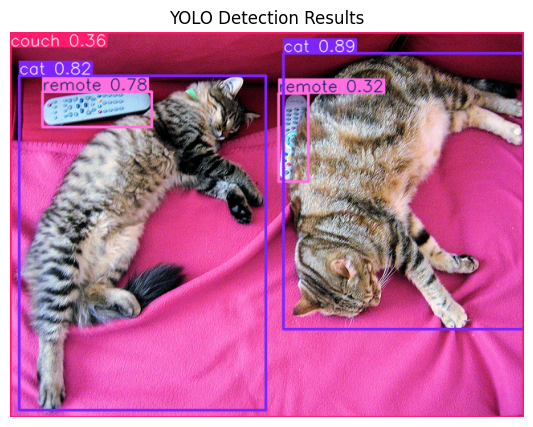

In [20]:
# SPEAKER NOTE: "YOLO: 3 lines of code, real-time speed."
# RUN TIME: ~5 seconds

from ultralytics import YOLO

# YOLO inference -- 3 lines
yolo_det = YOLO('yolov8n.pt')
yolo_results = yolo_det(det_image, verbose=False)

# Display YOLO results
yolo_img = Image.fromarray(yolo_results[0].plot()[:, :, ::-1])  # BGR to RGB

print("=== YOLO Results ===")
for box in yolo_results[0].boxes:
    cls_name = yolo_det.names[int(box.cls)]
    conf = float(box.conf)
    print(f"  {cls_name:15s}  confidence={conf:.1%}")

plt.figure(figsize=(8, 5))
plt.imshow(yolo_img)
plt.title("YOLO Detection Results")
plt.axis('off')
plt.show()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


=== DETR Results ===
  remote           confidence=99.8%
  remote           confidence=99.6%
  couch            confidence=99.5%
  cat              confidence=99.9%
  cat              confidence=99.9%


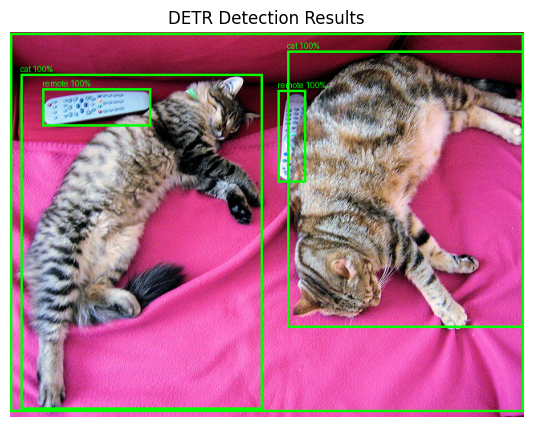

In [21]:
# SPEAKER NOTE: "Now DETR -- a transformer-based detector. Same image, different approach."
# RUN TIME: ~15 seconds (model download + inference)

from transformers import pipeline

# DETR inference
detector = pipeline("object-detection", model="facebook/detr-resnet-50")
detr_results = detector(det_image)

print("=== DETR Results ===")
for det in detr_results:
    print(f"  {det['label']:15s}  confidence={det['score']:.1%}")

# Draw DETR bounding boxes
from PIL import ImageDraw
detr_img = det_image.copy()
draw = ImageDraw.Draw(detr_img)
for det in detr_results:
    box = det["box"]
    label = f"{det['label']} {det['score']:.0%}"
    draw.rectangle([box["xmin"], box["ymin"], box["xmax"], box["ymax"]], outline="lime", width=3)
    draw.text((box["xmin"], box["ymin"] - 12), label, fill="lime")

plt.figure(figsize=(8, 5))
plt.imshow(detr_img)
plt.title("DETR Detection Results")
plt.axis('off')
plt.show()

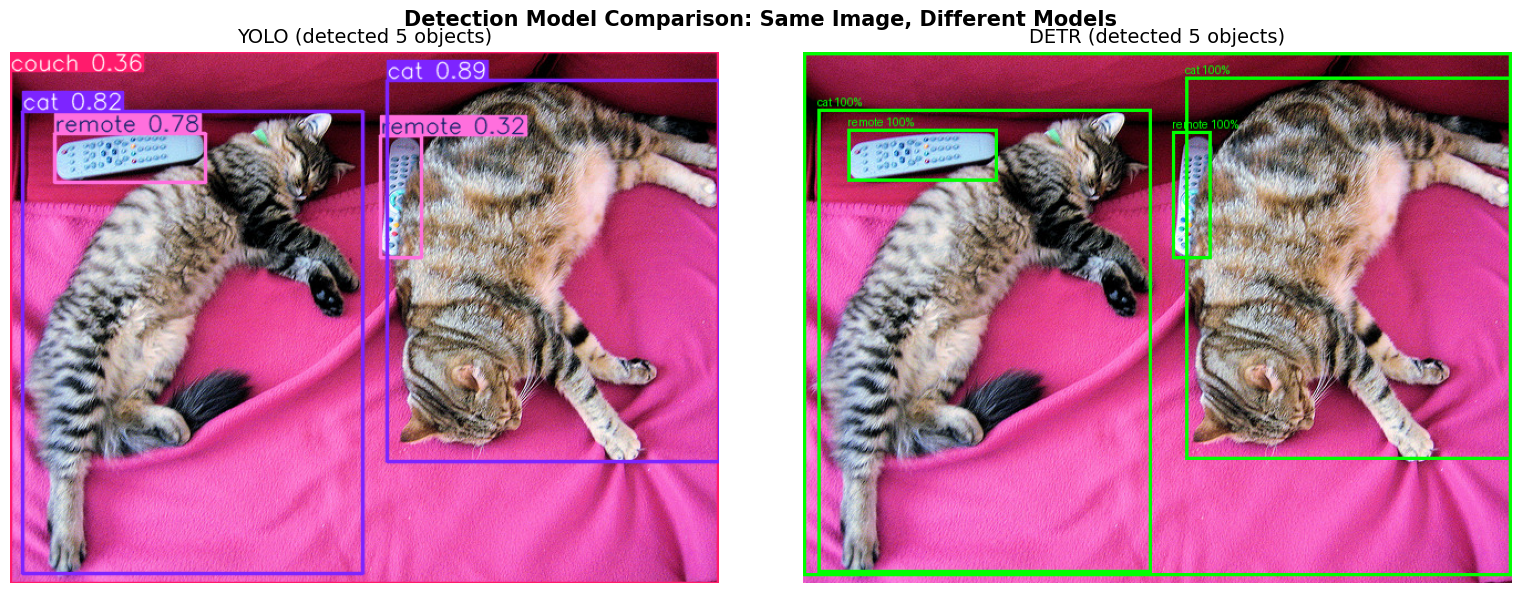

In [22]:
# SPEAKER NOTE: "Side by side -- same image, two approaches. Let's compare."
# RUN TIME: instant

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(yolo_img)
axes[0].set_title(f"YOLO (detected {len(yolo_results[0].boxes)} objects)", fontsize=14)
axes[0].axis('off')

axes[1].imshow(detr_img)
axes[1].set_title(f"DETR (detected {len(detr_results)} objects)", fontsize=14)
axes[1].axis('off')

plt.suptitle("Detection Model Comparison: Same Image, Different Models", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Detection Model Comparison

| | YOLO | DETR | RT-DETR |
|--|------|------|--------|
| Speed | Fastest | Slow | Fast |
| Accuracy | Good | Best on complex scenes | Good+ |
| Ease of use | Easiest (3 lines) | Medium | Medium |
| Fine-tuning | 3 lines with Ultralytics | More complex (HF Trainer) | More complex |
| Library | Ultralytics | HuggingFace | HuggingFace |
| **Hackathon pick** | **Default choice** | Only if YOLO is not accurate enough | Advanced users |

**Rule of thumb:** Start with YOLO. It is faster to run, faster to fine-tune, and easier to debug. Only switch to DETR if you specifically need better accuracy on crowded/overlapping scenes.

**Fine-tuning YOLO on your data (just 3 lines!):**
```python
model = YOLO('yolov8n.pt')
model.train(data='my_dataset.yaml', epochs=50, imgsz=640)
results = model('test_image.jpg')
```

---
## Cell Group 7: SAM2 Segmentation Demo (5 min) -- FLEX

**Segment Anything Model 2 (SAM2)** by Meta -- point at anything in an image, get a perfect mask.

This is the cutting edge of computer vision.

In [23]:
# SPEAKER NOTE: "SAM2 is Meta's Segment Anything Model. Click on any object
#   and it gives you a perfect segmentation mask. Let me show you."
# RUN TIME: ~20 seconds (model download + inference)

# Install SAM2 (the HuggingFace version for easy loading)
!pip install -q segment-anything-2 2>/dev/null || echo "SAM2 package not available, using HF pipeline instead"

SAM2 package not available, using HF pipeline instead


In [24]:
# SPEAKER NOTE: "We will use the HuggingFace pipeline for SAM -- it handles all
#   the setup for us. One line to load, one line to segment."
# RUN TIME: ~30 seconds (model download first time)

from transformers import pipeline
import numpy as np

# Load SAM via HuggingFace (works even without the standalone SAM2 package)
try:
    sam_pipe = pipeline(
        "mask-generation",
        model="facebook/sam-vit-base",
        device=0 if torch.cuda.is_available() else -1
    )
    print("SAM model loaded successfully!")
    print(f"Running on: {'GPU' if torch.cuda.is_available() else 'CPU'}")
except Exception as e:
    print(f"Could not load SAM model: {e}")
    print("This can happen on CPU-only Colab. The demo will still show the concept.")
    sam_pipe = None

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


SAM model loaded successfully!
Running on: GPU


SAM found 11 segments in the image!


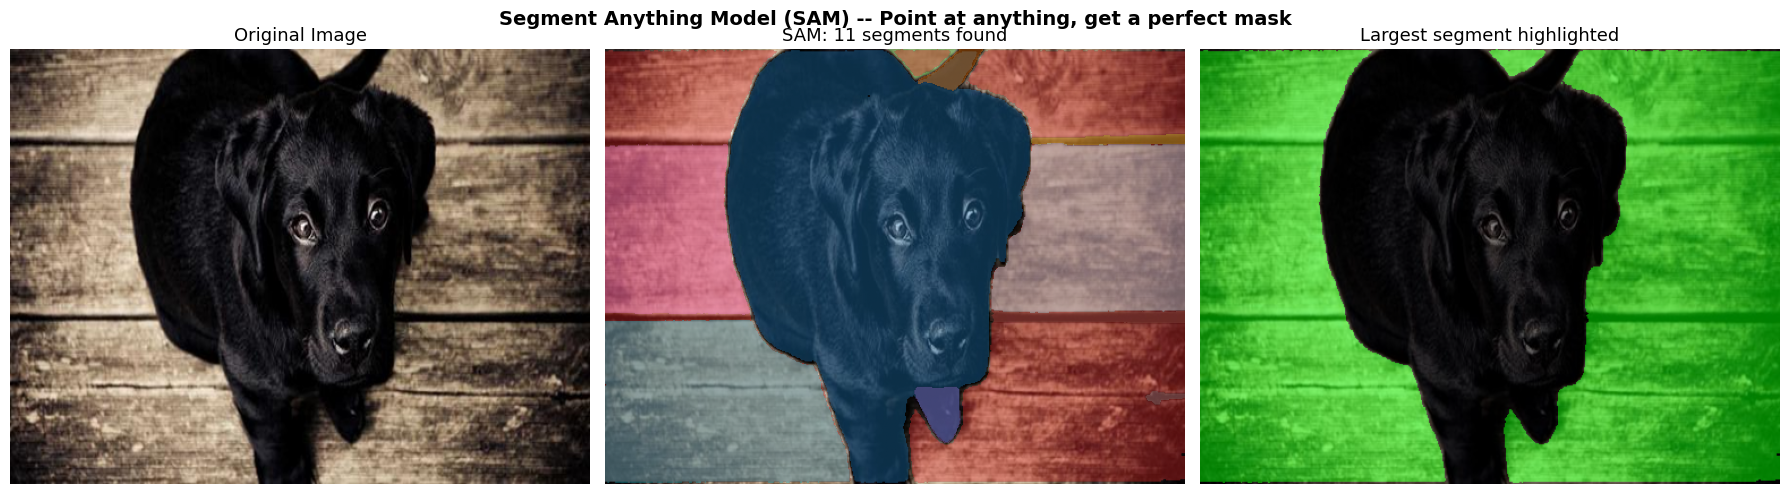

In [25]:
# SPEAKER NOTE: "SAM segments EVERYTHING in the image automatically.
#   Watch -- it finds every object and draws a perfect mask around it."
# RUN TIME: ~10-20 seconds

if sam_pipe is not None:
    # Resize image for faster processing
    sam_image = sample_image.resize((512, 384))

    # Generate masks -- SAM finds all objects automatically
    outputs = sam_pipe(sam_image, points_per_batch=32)

    print(f"SAM found {len(outputs['masks'])} segments in the image!")

    # Visualize the top masks with colorful overlays
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Original
    axes[0].imshow(sam_image)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis('off')

    # All masks overlaid
    axes[1].imshow(sam_image)
    colors = plt.cm.tab20(np.linspace(0, 1, min(len(outputs['masks']), 20)))
    for idx, mask in enumerate(outputs['masks'][:20]):
        mask_array = np.array(mask)
        colored_mask = np.zeros((*mask_array.shape, 4))
        color = colors[idx % len(colors)]
        colored_mask[mask_array] = [*color[:3], 0.4]  # RGBA with transparency
        axes[1].imshow(colored_mask)
    axes[1].set_title(f"SAM: {len(outputs['masks'])} segments found", fontsize=13)
    axes[1].axis('off')

    # Largest mask highlighted
    if len(outputs['masks']) > 0:
        # Sort by mask area, show the largest
        mask_areas = [np.array(m).sum() for m in outputs['masks']]
        largest_idx = np.argmax(mask_areas)
        axes[2].imshow(sam_image)
        largest_mask = np.array(outputs['masks'][largest_idx])
        highlight = np.zeros((*largest_mask.shape, 4))
        highlight[largest_mask] = [0, 1, 0, 0.5]  # Green overlay
        highlight[~largest_mask] = [0, 0, 0, 0.5]  # Darken background
        axes[2].imshow(highlight)
        axes[2].set_title("Largest segment highlighted", fontsize=13)
        axes[2].axis('off')

    plt.suptitle("Segment Anything Model (SAM) -- Point at anything, get a perfect mask",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("SAM demo skipped (model not loaded).")
    print("To run this on your own: open Colab, enable GPU, and re-run this cell.")
    print()
    print("What SAM does:")
    print("  1. Takes any image as input")
    print("  2. Automatically finds all objects")
    print("  3. Creates pixel-perfect masks for each object")
    print("  4. Works on objects it has NEVER seen before")
    print("  5. No training needed -- it works zero-shot")

### Why SAM Matters

- **Zero-shot segmentation** -- works on objects it has never seen during training
- **Point prompts** -- click on an object, get a mask
- **Box prompts** -- draw a rough box, get a precise mask
- **SAM2 adds video** -- segment objects across video frames

**For hackathons:** SAM is great for:
- Creating training data (segment objects to build a dataset)
- Any task requiring precise object boundaries
- Impressing judges with visual results

---
## Cell Group 8: Architecture Cheat Sheet (2 min) -- CORE

Screenshot this. This is your reference card for every hackathon.

### Model Selection Cheat Sheet

| Task | Model | Library | Code | Size |
|------|-------|---------|------|------|
| Classification (small data) | ResNet-18 | torchvision | `models.resnet18(weights='IMAGENET1K_V1')` | 45 MB |
| Classification (best accuracy/param) | EfficientNet-B0 | torchvision | `models.efficientnet_b0(weights='IMAGENET1K_V1')` | 21 MB |
| Classification (large data) | ViT-Base | HuggingFace | `ViTForImageClassification.from_pretrained(...)` | 330 MB |
| Object Detection | YOLOv8-nano | Ultralytics | `YOLO('yolov8n.pt')` | 6 MB |
| Segmentation | SAM | Meta / HuggingFace | `pipeline('mask-generation', model='facebook/sam-vit-base')` | 375 MB |
| OCR (Thai) | EasyOCR | easyocr | `reader = easyocr.Reader(['en', 'th'])` | ~100 MB |

### Transfer Learning Quick Reference

| Dataset Size | Strategy | Code Pattern |
|-------------|----------|-------------|
| < 500 images | Freeze all, train head | `for p in model.parameters(): p.requires_grad = False` |
| 500-5000 | Unfreeze last block | Freeze all, then `for p in model.layer4.parameters(): p.requires_grad = True` |
| 5000+ | Fine-tune all | `optimizer = Adam(model.parameters(), lr=0.0001)` |

### ImageNet Normalization (use these ALWAYS with pretrained models)
```python
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
```

---
## Cell Group 9: Hackathon Connection

### Which Model for Which Past Super AI Hackathon Task?

| Hackathon Task | Season | What to Use | Start With |
|---------------|--------|------------|------------|
| Thai handwriting recognition | S3 | Image Classification + Transfer Learning | ResNet-18 (Scenario 1) or EfficientNet-B0 |
| Image NER | S3 | Object Detection + OCR | YOLO + EasyOCR |
| Thai OCR | S4 | Detection + Recognition pipeline | EasyOCR (supports Thai natively) |
| Image Captioning | S4 | Vision-Language model | BLIP-2 or Florence-2 |
| Binary image classification | 2024 | Transfer Learning | ResNet-18 -- exactly Scenario 1 above |
| Product detection | Any | Object Detection | YOLO fine-tuned on your product images |
| Document reading | Any | OCR pipeline | EasyOCR with `Reader(['th', 'en'])` |
| Any new image task | Any | Start simple, upgrade | ResNet-18 -> EfficientNet -> ViT |

### The Golden Rule

**Start with the simplest model that could work. Upgrade only when you have evidence that a more complex model will help.**

1. Start with ResNet-18 + Scenario 1 (freeze all)
2. If accuracy is not enough: try EfficientNet-B0 or Scenario 2 (unfreeze last block)
3. If still not enough: try ViT-Base or Scenario 3 (fine-tune everything)
4. If still not enough: ensemble 2-3 models and average predictions

In [ ]:
# SPEAKER NOTE: "Let's verify everything we covered works. Quick summary of all the models."
# RUN TIME: instant

print("=" * 60)
print("SUMMARY: Everything we covered today")
print("=" * 60)
print()
print("Model Zoo Libraries:")
print(f"  timm:          {len(timm.list_models())} models available")
print(f"  torchvision:   ~30 classification models")
print(f"  HuggingFace:   10,000+ vision models")
print(f"  Ultralytics:   5 YOLO sizes (nano to xlarge)")
print()
print("CNN Models (classification):")
print(f"  ResNet-18:        {count_params(resnet18):>12,} params")
print(f"  ResNet-50:        {count_params(resnet50):>12,} params")
print(f"  EfficientNet-B0:  {count_params(effnet):>12,} params")
print(f"  MobileNetV3-S:    {count_params(mobilenet):>12,} params")
print()
print("Transfer Learning Scenarios:")
print("  Scenario 1: <500 images  -> Freeze all, train head (lr=0.001)")
print("  Scenario 2: 500-5000     -> Unfreeze last block (lr=0.0001/0.001)")
print("  Scenario 3: 5000+        -> Fine-tune all (lr=0.0001)")
print()
print("Detection: YOLO (fast, easy) vs DETR (accurate, complex scenes)")
print("Segmentation: SAM (point and click, zero-shot)")
print()
print("Default hackathon stack:")
print("  Classification -> ResNet-18 + transfer learning")
print("  Detection      -> YOLO nano")
print("  Segmentation   -> SAM")
print("  OCR            -> EasyOCR")